# Show how to use `pcolormesh` to plot healpix data

* Mark Muetzelfeldt, mark.muetzelfeldt@reading.ac.uk
* Idea is to break the problem into 12 "faces" - level-0 pixels. Each face can then be plotted as a "square", so long as we can construct an index which runs in the same order as the nested healpix indices in each face.

In [1]:
import cartopy.crs as ccrs
import easygems.healpix as egh
import healpix as hp
import intake
import matplotlib.pyplot as plt
import numpy as np

/home/users/mmuetz/miniforge3/envs/hackathon_base_env/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


# Synthetic data

* It's easier to see what's going on with a low zoom to see how the mapping from healpix index to "square" of value that `pcolormesh` can use works.

In [2]:
z = 2
nside = 2**z
npix_per_face = nside**2

In [3]:
lon, lat = hp.pix2ang(nside, np.arange(12 * 4**z), nest=True, lonlat=True)

(-90.0, 90.0)

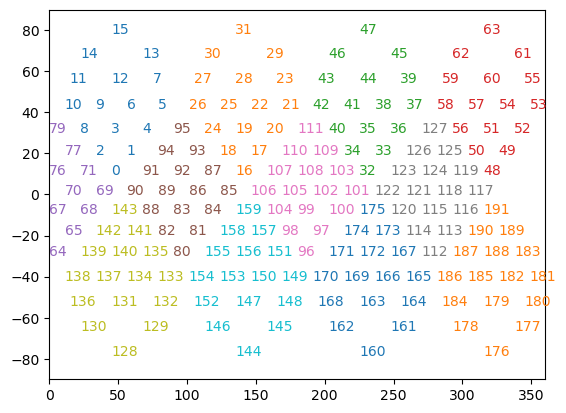

In [4]:
colours = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, x, y in zip(np.arange(12 * 4**z), lon, lat):
    c = colours[i // npix_per_face % len(colours)]
    plt.annotate(str(i), (x, y), c=c)
plt.xlim(0, 360)
plt.ylim(-90, 90)

* Look at the blue "square", top left. Index 0 is the first nested lat lon, at approx (60, 20). The indices are clearly not ordered such that you get a square when you run through them. We want to generate a sequence that goes `[0, 1, 4, 5, 2, 3, 6, 7, 8]`. We can do that with the following functions. 

In [5]:
# I am calling each of the 12 zoom-0 healpix levels a 'face'.
# These two funcs let you define the mapping between each face and the nested index at a given zoom.
def hp_face_level_next(a):
    a0 = np.arange(4).reshape((2, 2))
    tilesize = a.shape[0]
    return np.repeat(np.repeat(a, 2, axis=0), 2, axis=1) * 4 + np.tile(a0, (tilesize, tilesize))


def hp_face_level(zoom):
    a = np.arange(4).reshape((2, 2))
    for i in range(zoom - 1):
        a = hp_face_level_next(a)
    return a


In [6]:
#a = np.arange(npix_per_face)
fz = hp_face_level(z)
idx = fz.flatten()
idx

array([ 0,  1,  4,  5,  2,  3,  6,  7,  8,  9, 12, 13, 10, 11, 14, 15])

* This is the sequence we want! If we use the corresponding lon/lat they will form a "square"-ish shape squashed onto a sphere. Note, if we add 16 onto this, we get the sequence for the orange square, and so on.
* We can use this to plot 12 pcolormeshes, one for each "face". We do this for synthetic data:

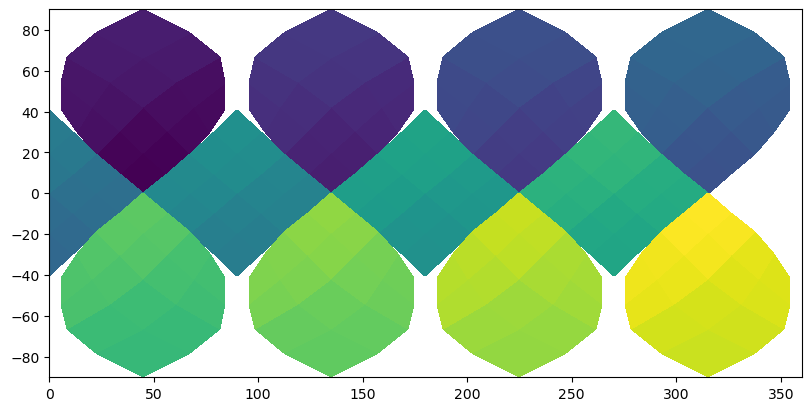

In [7]:
d = np.arange(12 * 4**z)
vmin = d.min()
vmax = d.max()

fig, ax = plt.subplots(figsize=(8, 4), layout='constrained')

ax.set_xlim(0, 360)
ax.set_ylim(-90, 90)

for i in range(12):
    if i in [-1]:
        continue
    dd = d[i * npix_per_face:(i + 1) * npix_per_face][idx].reshape(nside, nside)
    lat1 = lat[i * npix_per_face:(i + 1) * npix_per_face][idx].reshape(nside, nside)
    lon1 = lon[i * npix_per_face:(i + 1) * npix_per_face][idx].reshape(nside, nside)
    # lat1, lon1 are centroid locations. I think you would get better results by defining edges.
    ax.pcolormesh(lon1, lat1, dd, vmin=vmin, vmax=vmax)

* This is a plot of the z=2 healpix grid of a range of 12 * 4**2 values. Note, `pcolormesh` does know where to put the boundaries properly -- it would be better if I knew how to calculate the vertices of the gid to feed to pcolormesh. 

# Real data (well simulations anyway)

In [8]:
cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['UK']
# Open a dataset.
ds = cat['um_glm_n2560_RAL3p3'](zoom=8, time='PT1H').to_dask().pipe(egh.attach_coords)

/home/users/mmuetz/miniforge3/envs/hackathon_base_env/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [9]:
nside = ds.crs.healpix_nside  # number of pixels per side of the 12 level-0 pixels.
z = int(np.log2(nside))
(nside, z)

(256, 8)

In [10]:
npix_per_face = nside**2  # number of pixels per "face" - per level-0 pixel.
npix_per_face

65536

In [11]:
fz = hp_face_level(z)
idx = fz.flatten()

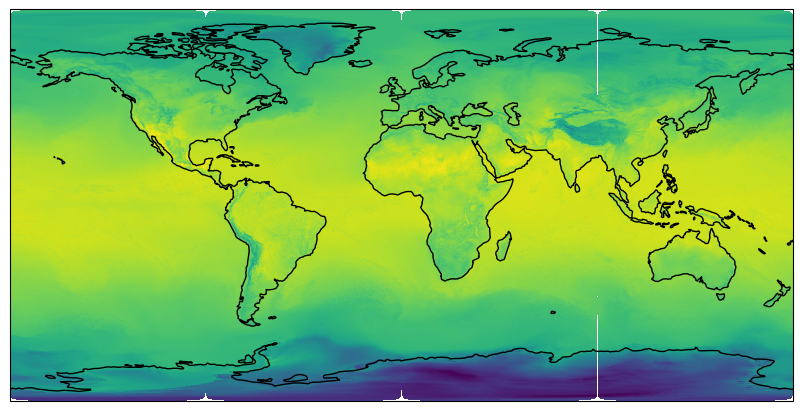

In [12]:
d = ds.tas.sel(time='2020-05-13 00:00').values
vmin = d.min()
vmax = d.max()
lat = ds.lat.values
lon = ds.lon.values

fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": ccrs.PlateCarree()}, layout='constrained')


for i in range(12):
    if i in [-1]:
        continue
    dd = d[i * npix_per_face:(i + 1) * npix_per_face][idx].reshape(nside, nside)
    lat1 = lat[i * npix_per_face:(i + 1) * npix_per_face][idx].reshape(nside, nside)
    lon1 = lon[i * npix_per_face:(i + 1) * npix_per_face][idx].reshape(nside, nside)
    # lat1, lon1 are centroid locations. I think you would get better results by defining edges.
    ax.pcolormesh(lon1, lat1, dd, vmin=vmin, vmax=vmax)
ax.coastlines()

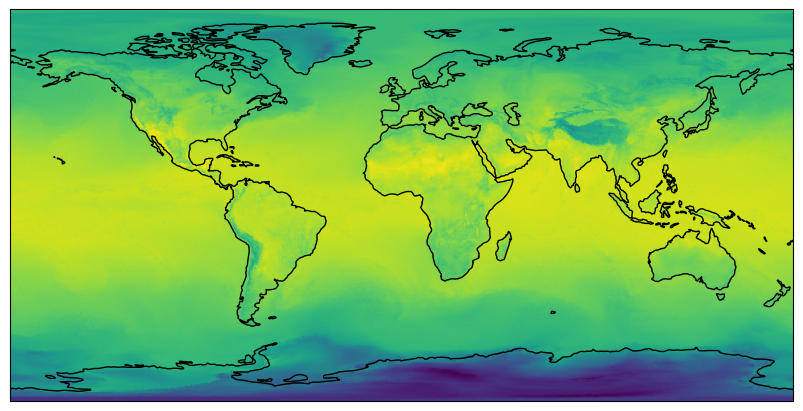

In [13]:
fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": ccrs.PlateCarree()}, layout='constrained')
ax.set_global()
egh.healpix_show(d, vmin=vmin, vmax=vmax)
ax.coastlines()